# Perceptrón, MLP y Redes Profundas

**Aprendizaje Profundo - UNSAM**

En este notebook cubriremos:
1. El Perceptrón: la neurona artificial básica
2. Redes Neuronales Multicapa (MLP)
3. Redes Profundas (Deep Neural Networks)
4. Entrenamiento y optimización
5. Aplicaciones prácticas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configuración
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 1. El Perceptrón

El perceptrón es la unidad básica de una red neuronal. Realiza una combinación lineal de las entradas y aplica una función de activación.

$$y = f(\sum_{i=1}^{n} w_i x_i + b)$$

donde:
- $x_i$ son las entradas
- $w_i$ son los pesos
- $b$ es el sesgo (bias)
- $f$ es la función de activación

### Implementación Manual del Perceptrón

In [14]:
class Perceptron:
    """Perceptrón simple para clasificación binaria."""
    
    def __init__(self, input_size, learning_rate=0.01):
        self.weights = torch.randn(input_size, requires_grad=True)
        self.bias = torch.randn(1, requires_grad=True)
        self.lr = learning_rate
    
    def forward(self, x):
        """Propagación hacia adelante."""
        # Asegurar que x sea 2D (batch_size, features)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        linear = torch.matmul(x, self.weights) + self.bias
        # Función de activación escalón
        return torch.where(linear >= 0, torch.tensor(1.0), torch.tensor(0.0)).unsqueeze(-1)
    
    def train_step(self, x, y):
        """Un paso de entrenamiento."""
        # Predicción
        pred = self.forward(x)
        
        # Calcular error
        error = y - pred
        
        # Actualizar pesos (regla de aprendizaje del perceptrón)
        with torch.no_grad():
            self.weights += self.lr * torch.matmul(x.t(), error).squeeze()
            self.bias += self.lr * error.sum()
        
        return error.abs().sum().item()

# Datos de ejemplo: puerta lógica AND
X_and = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_and = torch.tensor([[0.], [0.], [0.], [1.]])

print("Entrenando perceptrón para la puerta AND")
perceptron = Perceptron(input_size=2, learning_rate=0.1)

# Entrenar
epochs = 20
for epoch in range(epochs):
    error = perceptron.train_step(X_and, y_and)
    if epoch % 5 == 0:
        print(f"Época {epoch}: Error = {error}")

# Probar
print("\nResultados:")
for x, y in zip(X_and, y_and):
    pred = perceptron.forward(x)
    print(f"Entrada: {x.numpy()}, Predicción: {pred.item():.0f}, Real: {y.item():.0f}")

Entrenando perceptrón para la puerta AND
Época 0: Error = 1.0
Época 5: Error = 2.0
Época 10: Error = 1.0
Época 15: Error = 0.0

Resultados:
Entrada: [0. 0.], Predicción: 0, Real: 0
Entrada: [0. 1.], Predicción: 0, Real: 0
Entrada: [1. 0.], Predicción: 0, Real: 0
Entrada: [1. 1.], Predicción: 1, Real: 1


### Limitaciones del Perceptrón: Problema XOR

El perceptrón solo puede resolver problemas linealmente separables. El XOR no lo es.

Intentando entrenar perceptrón para XOR
Época 0: Error = 2.0
Época 20: Error = 2.0
Época 40: Error = 2.0
Época 60: Error = 2.0
Época 80: Error = 2.0

Resultados (el perceptrón NO puede aprender XOR):
Entrada: [0. 0.], Predicción: 0, Real: 0
Entrada: [0. 1.], Predicción: 0, Real: 1
Entrada: [1. 0.], Predicción: 0, Real: 1
Entrada: [1. 1.], Predicción: 0, Real: 0


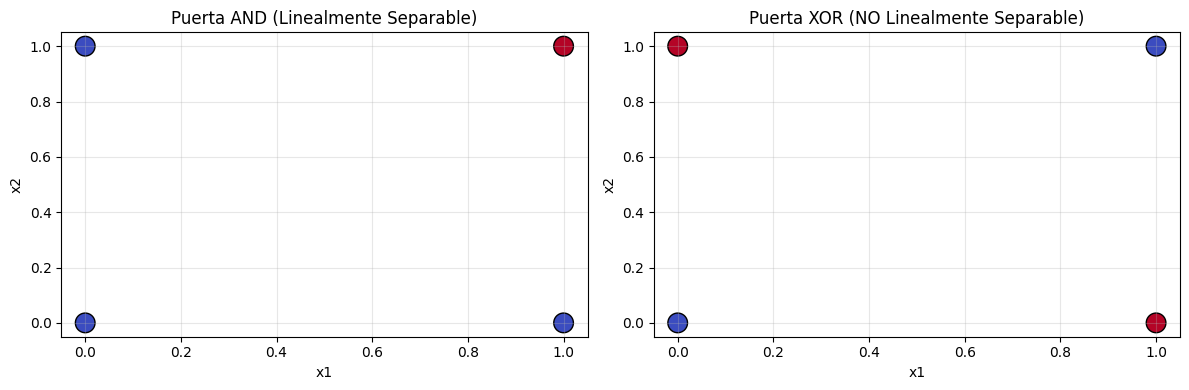

In [15]:
# Datos XOR
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

print("Intentando entrenar perceptrón para XOR")
perceptron_xor = Perceptron(input_size=2, learning_rate=0.1)

epochs = 100
for epoch in range(epochs):
    error = perceptron_xor.train_step(X_xor, y_xor)
    if epoch % 20 == 0:
        print(f"Época {epoch}: Error = {error}")

print("\nResultados (el perceptrón NO puede aprender XOR):")
for x, y in zip(X_xor, y_xor):
    pred = perceptron_xor.forward(x.unsqueeze(0))  # Add batch dimension
    print(f"Entrada: {x.numpy()}, Predicción: {pred.item():.0f}, Real: {y.item():.0f}")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# AND
ax1.scatter(X_and[:, 0], X_and[:, 1], c=y_and.flatten(), cmap='coolwarm', s=200, edgecolors='k')
ax1.set_title('Puerta AND (Linealmente Separable)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.grid(True, alpha=0.3)

# XOR
ax2.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.flatten(), cmap='coolwarm', s=200, edgecolors='k')
ax2.set_title('Puerta XOR (NO Linealmente Separable)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Funciones de Activación

Las funciones de activación introducen no-linealidad en la red.

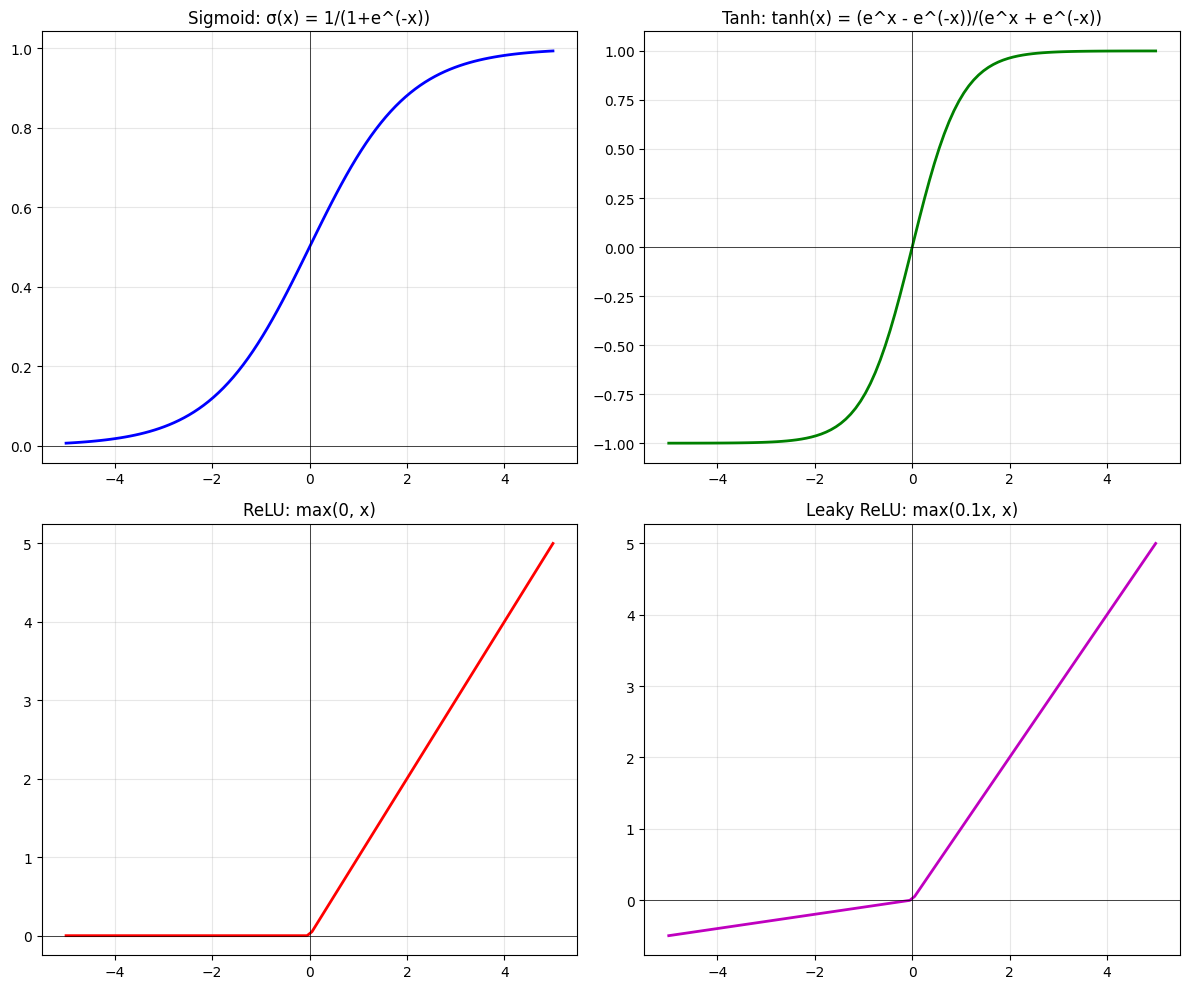


Características de las funciones de activación:

Sigmoid:
  - Rango: (0, 1)
  - Uso: Capa de salida para probabilidades
  - Problema: Desvanecimiento de gradiente

Tanh:
  - Rango: (-1, 1)
  - Uso: Capas ocultas
  - Mejor que sigmoid (centrada en cero)

ReLU:
  - Rango: [0, ∞)
  - Uso: Capas ocultas (más común)
  - Ventajas: Rápida, evita desvanecimiento
  - Problema: Neuronas 'muertas'

Leaky ReLU:
  - Rango: (-∞, ∞)
  - Soluciona problema de neuronas muertas


In [16]:
# Visualizar funciones de activación comunes
x = torch.linspace(-5, 5, 100)

# Definir funciones
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = F.relu(x)
leaky_relu = F.leaky_relu(x, negative_slope=0.1)

# Graficar
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(x.numpy(), sigmoid.numpy(), 'b-', linewidth=2)
axes[0, 0].set_title('Sigmoid: σ(x) = 1/(1+e^(-x))', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linewidth=0.5)
axes[0, 0].axvline(x=0, color='k', linewidth=0.5)

axes[0, 1].plot(x.numpy(), tanh.numpy(), 'g-', linewidth=2)
axes[0, 1].set_title('Tanh: tanh(x) = (e^x - e^(-x))/(e^x + e^(-x))', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linewidth=0.5)
axes[0, 1].axvline(x=0, color='k', linewidth=0.5)

axes[1, 0].plot(x.numpy(), relu.numpy(), 'r-', linewidth=2)
axes[1, 0].set_title('ReLU: max(0, x)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linewidth=0.5)
axes[1, 0].axvline(x=0, color='k', linewidth=0.5)

axes[1, 1].plot(x.numpy(), leaky_relu.numpy(), 'm-', linewidth=2)
axes[1, 1].set_title('Leaky ReLU: max(0.1x, x)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='k', linewidth=0.5)
axes[1, 1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nCaracterísticas de las funciones de activación:")
print("\nSigmoid:")
print("  - Rango: (0, 1)")
print("  - Uso: Capa de salida para probabilidades")
print("  - Problema: Desvanecimiento de gradiente")

print("\nTanh:")
print("  - Rango: (-1, 1)")
print("  - Uso: Capas ocultas")
print("  - Mejor que sigmoid (centrada en cero)")

print("\nReLU:")
print("  - Rango: [0, ∞)")
print("  - Uso: Capas ocultas (más común)")
print("  - Ventajas: Rápida, evita desvanecimiento")
print("  - Problema: Neuronas 'muertas'")

print("\nLeaky ReLU:")
print("  - Rango: (-∞, ∞)")
print("  - Soluciona problema de neuronas muertas")

## 3. Red Neuronal Multicapa (MLP)

Un MLP consta de múltiples capas de neuronas conectadas. Puede resolver problemas no lineales como XOR.

### Implementación en PyTorch

In [17]:
class SimpleMLP(nn.Module):
    """MLP simple con una capa oculta."""
    
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        # Definir capas
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Capa oculta con activación
        x = self.fc1(x)
        x = torch.sigmoid(x)
        
        # Capa de salida
        x = self.fc2(x)
        x = torch.sigmoid(x)
        
        return x

# Crear modelo para XOR
model_xor = SimpleMLP(input_size=2, hidden_size=4, output_size=1)
print(model_xor)
print(f"\nNúmero de parámetros: {sum(p.numel() for p in model_xor.parameters())}")

SimpleMLP(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)

Número de parámetros: 17


### Entrenamiento del MLP para XOR

Época [1000/5000], Pérdida: 0.6600
Época [2000/5000], Pérdida: 0.0244
Época [3000/5000], Pérdida: 0.0096
Época [4000/5000], Pérdida: 0.0059
Época [5000/5000], Pérdida: 0.0042

Resultados:
Entrada: [0. 0.], Predicción: 0.0017, Real: 0
Entrada: [0. 1.], Predicción: 0.9935, Real: 1
Entrada: [1. 0.], Predicción: 0.9970, Real: 1
Entrada: [1. 1.], Predicción: 0.0057, Real: 0


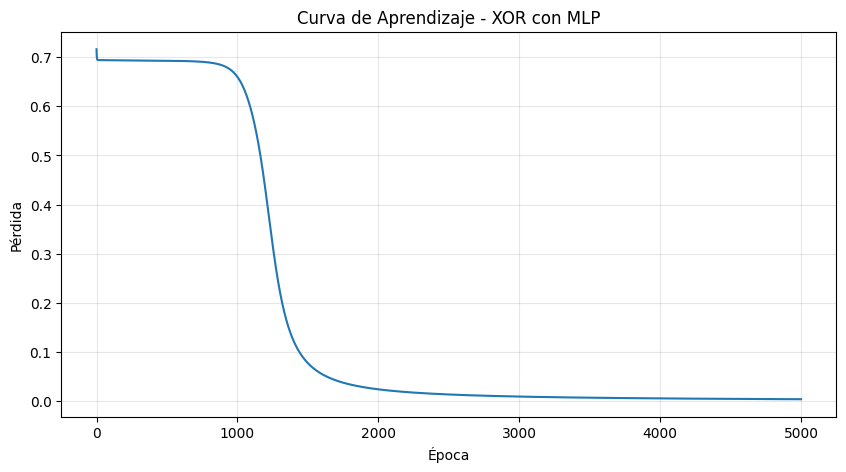

In [18]:
# Datos XOR
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

# Definir función de pérdida y optimizador
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.SGD(model_xor.parameters(), lr=0.5)

# Entrenar
epochs = 5000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = model_xor(X_xor)
    loss = criterion(outputs, y_xor)
    
    # Backward pass y optimización
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 1000 == 0:
        print(f'Época [{epoch+1}/{epochs}], Pérdida: {loss.item():.4f}')

# Evaluar
with torch.no_grad():
    predictions = model_xor(X_xor)
    print("\nResultados:")
    for x, y, pred in zip(X_xor, y_xor, predictions):
        print(f"Entrada: {x.numpy()}, Predicción: {pred.item():.4f}, Real: {y.item():.0f}")

# Graficar pérdida
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curva de Aprendizaje - XOR con MLP')
plt.grid(True, alpha=0.3)
plt.show()

### Visualización de la Frontera de Decisión

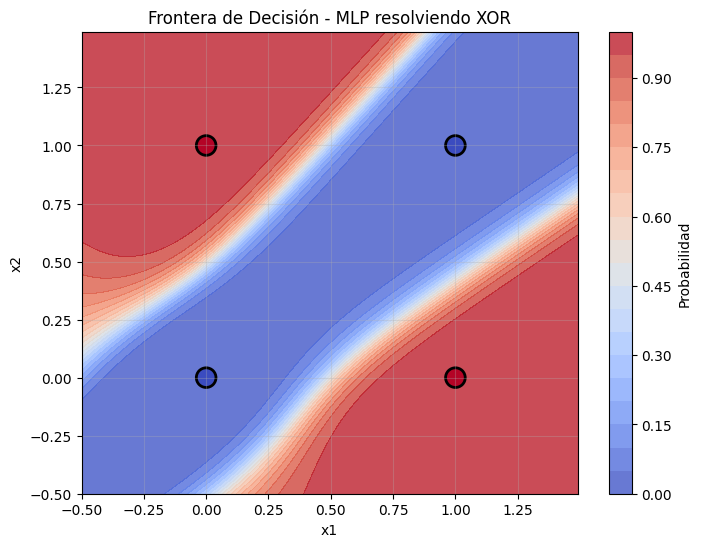

In [19]:
def plot_decision_boundary(model, X, y, title=''):
    """Visualizar frontera de decisión."""
    # Crear malla
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predecir en la malla
    mesh_input = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(mesh_input).numpy()
    Z = Z.reshape(xx.shape)
    
    # Graficar
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm', levels=20)
    plt.colorbar(label='Probabilidad')
    
    # Graficar puntos
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='coolwarm', 
                s=200, edgecolors='k', linewidth=2)
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model_xor, X_xor, y_xor, 
                      'Frontera de Decisión - MLP resolviendo XOR')

## 4. Redes Profundas

Ahora construiremos redes con múltiples capas ocultas y las probaremos en datasets más complejos.

### Generación de Datasets

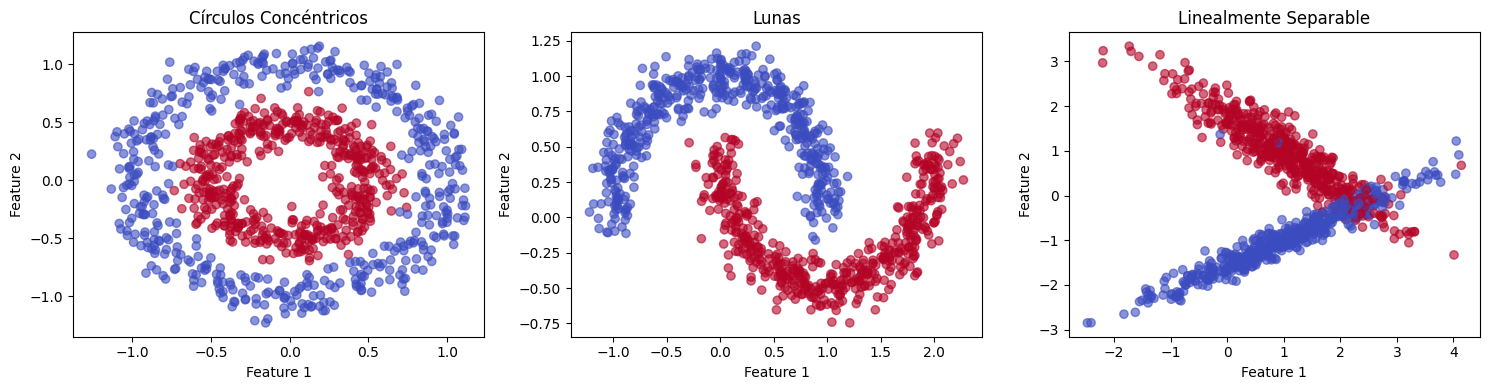

In [20]:
# Generar diferentes datasets
n_samples = 1000

# Dataset 1: Circulos concéntricos
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.1, factor=0.5, random_state=42)

# Dataset 2: Lunas
X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

# Dataset 3: Clasificación lineal
X_linear, y_linear = make_classification(n_samples=n_samples, n_features=2, n_redundant=0,
                                         n_informative=2, n_clusters_per_class=1,
                                         random_state=42)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', alpha=0.6)
axes[0].set_title('Círculos Concéntricos')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', alpha=0.6)
axes[1].set_title('Lunas')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

axes[2].scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', alpha=0.6)
axes[2].set_title('Linealmente Separable')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

### Red Neuronal Profunda

In [21]:
class DeepNN(nn.Module):
    """Red neuronal profunda con múltiples capas ocultas."""
    
    def __init__(self, input_size, hidden_sizes, output_size, activation='relu'):
        super(DeepNN, self).__init__()
        
        # Construir capas
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            prev_size = hidden_size
        
        # Capa de salida
        layers.append(nn.Linear(prev_size, output_size))
        
        self.layers = nn.ModuleList(layers)
        self.activation = activation
    
    def forward(self, x):
        # Capas ocultas con activación
        for layer in self.layers[:-1]:
            x = layer(x)
            if self.activation == 'relu':
                x = F.relu(x)
            elif self.activation == 'tanh':
                x = torch.tanh(x)
            elif self.activation == 'sigmoid':
                x = torch.sigmoid(x)
        
        # Capa de salida
        x = self.layers[-1](x)
        x = torch.sigmoid(x)
        
        return x

# Crear diferentes arquitecturas
shallow_net = DeepNN(input_size=2, hidden_sizes=[8], output_size=1)
medium_net = DeepNN(input_size=2, hidden_sizes=[16, 8], output_size=1)
deep_net = DeepNN(input_size=2, hidden_sizes=[32, 16, 8], output_size=1)

print("Red Superficial (1 capa oculta):")
print(shallow_net)
print(f"Parámetros: {sum(p.numel() for p in shallow_net.parameters())}")

print("\nRed Media (2 capas ocultas):")
print(medium_net)
print(f"Parámetros: {sum(p.numel() for p in medium_net.parameters())}")

print("\nRed Profunda (3 capas ocultas):")
print(deep_net)
print(f"Parámetros: {sum(p.numel() for p in deep_net.parameters())}")

Red Superficial (1 capa oculta):
DeepNN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=1, bias=True)
  )
)
Parámetros: 33

Red Media (2 capas ocultas):
DeepNN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
Parámetros: 193

Red Profunda (3 capas ocultas):
DeepNN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Linear(in_features=8, out_features=1, bias=True)
  )
)
Parámetros: 769


### Función de Entrenamiento

In [22]:
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=1000, lr=0.01, verbose=True):
    """Entrenar un modelo."""
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validación
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
        
        if verbose and (epoch + 1) % 200 == 0:
            print(f'Época [{epoch+1}/{epochs}], '
                  f'Pérdida Entrenamiento: {loss.item():.4f}, '
                  f'Pérdida Validación: {val_loss.item():.4f}')
    
    return train_losses, val_losses

def evaluate_model(model, X, y):
    """Evaluar un modelo."""
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        predictions = (outputs >= 0.5).float()
        accuracy = (predictions == y).float().mean()
    return accuracy.item()

### Entrenar en Dataset de Círculos

Entrenando Red Profunda en Círculos...
Época [200/1000], Pérdida Entrenamiento: 0.0012, Pérdida Validación: 0.0455
Época [400/1000], Pérdida Entrenamiento: 0.0004, Pérdida Validación: 0.0517
Época [600/1000], Pérdida Entrenamiento: 0.0002, Pérdida Validación: 0.0558
Época [800/1000], Pérdida Entrenamiento: 0.0001, Pérdida Validación: 0.0628
Época [1000/1000], Pérdida Entrenamiento: 0.0000, Pérdida Validación: 0.0704

Precisión Entrenamiento: 1.0000
Precisión Test: 0.9800


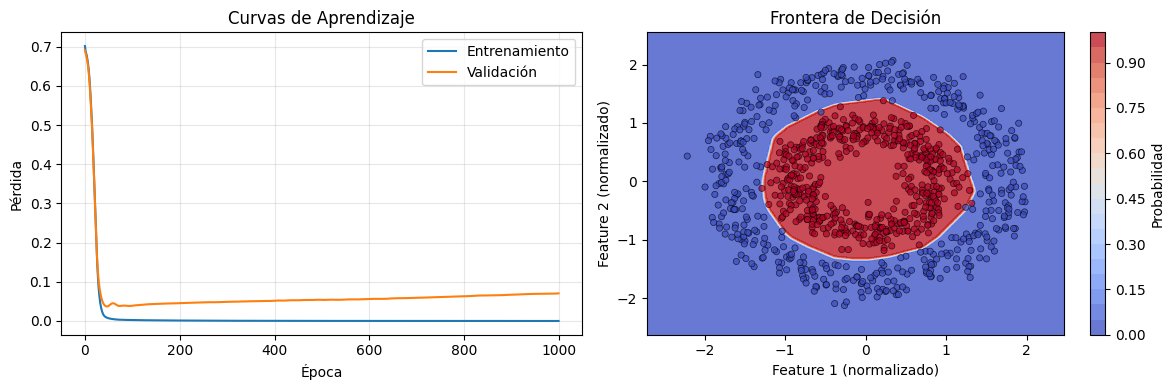

In [23]:
# Preparar datos
X_train, X_test, y_train, y_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=42
)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)

# Entrenar red profunda
print("Entrenando Red Profunda en Círculos...")
model_circles = DeepNN(input_size=2, hidden_sizes=[32, 16, 8], output_size=1)
train_losses, val_losses = train_model(
    model_circles, X_train_t, y_train_t, X_test_t, y_test_t,
    epochs=1000, lr=0.01
)

# Evaluar
train_acc = evaluate_model(model_circles, X_train_t, y_train_t)
test_acc = evaluate_model(model_circles, X_test_t, y_test_t)
print(f"\nPrecisión Entrenamiento: {train_acc:.4f}")
print(f"Precisión Test: {test_acc:.4f}")

# Graficar pérdidas
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True, alpha=0.3)

# Preparar datos para visualización
X_vis = torch.FloatTensor(scaler.transform(X_circles))
y_vis = y_circles

plt.subplot(1, 2, 2)
h = 0.02
x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

mesh_input = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model_circles(mesh_input).numpy()
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm', levels=20)
plt.colorbar(label='Probabilidad')
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='coolwarm', 
           s=20, edgecolors='k', linewidth=0.5, alpha=0.7)
plt.title('Frontera de Decisión')
plt.xlabel('Feature 1 (normalizado)')
plt.ylabel('Feature 2 (normalizado)')

plt.tight_layout()
plt.show()

### Comparación de Arquitecturas


Entrenando arquitectura Superficial: [8]
Precisión Test: 0.8900, Parámetros: 33

Entrenando arquitectura Media: [16, 8]
Precisión Test: 1.0000, Parámetros: 193

Entrenando arquitectura Profunda: [32, 16, 8]
Precisión Test: 1.0000, Parámetros: 769

Entrenando arquitectura Muy Profunda: [64, 32, 16, 8]
Precisión Test: 1.0000, Parámetros: 2945


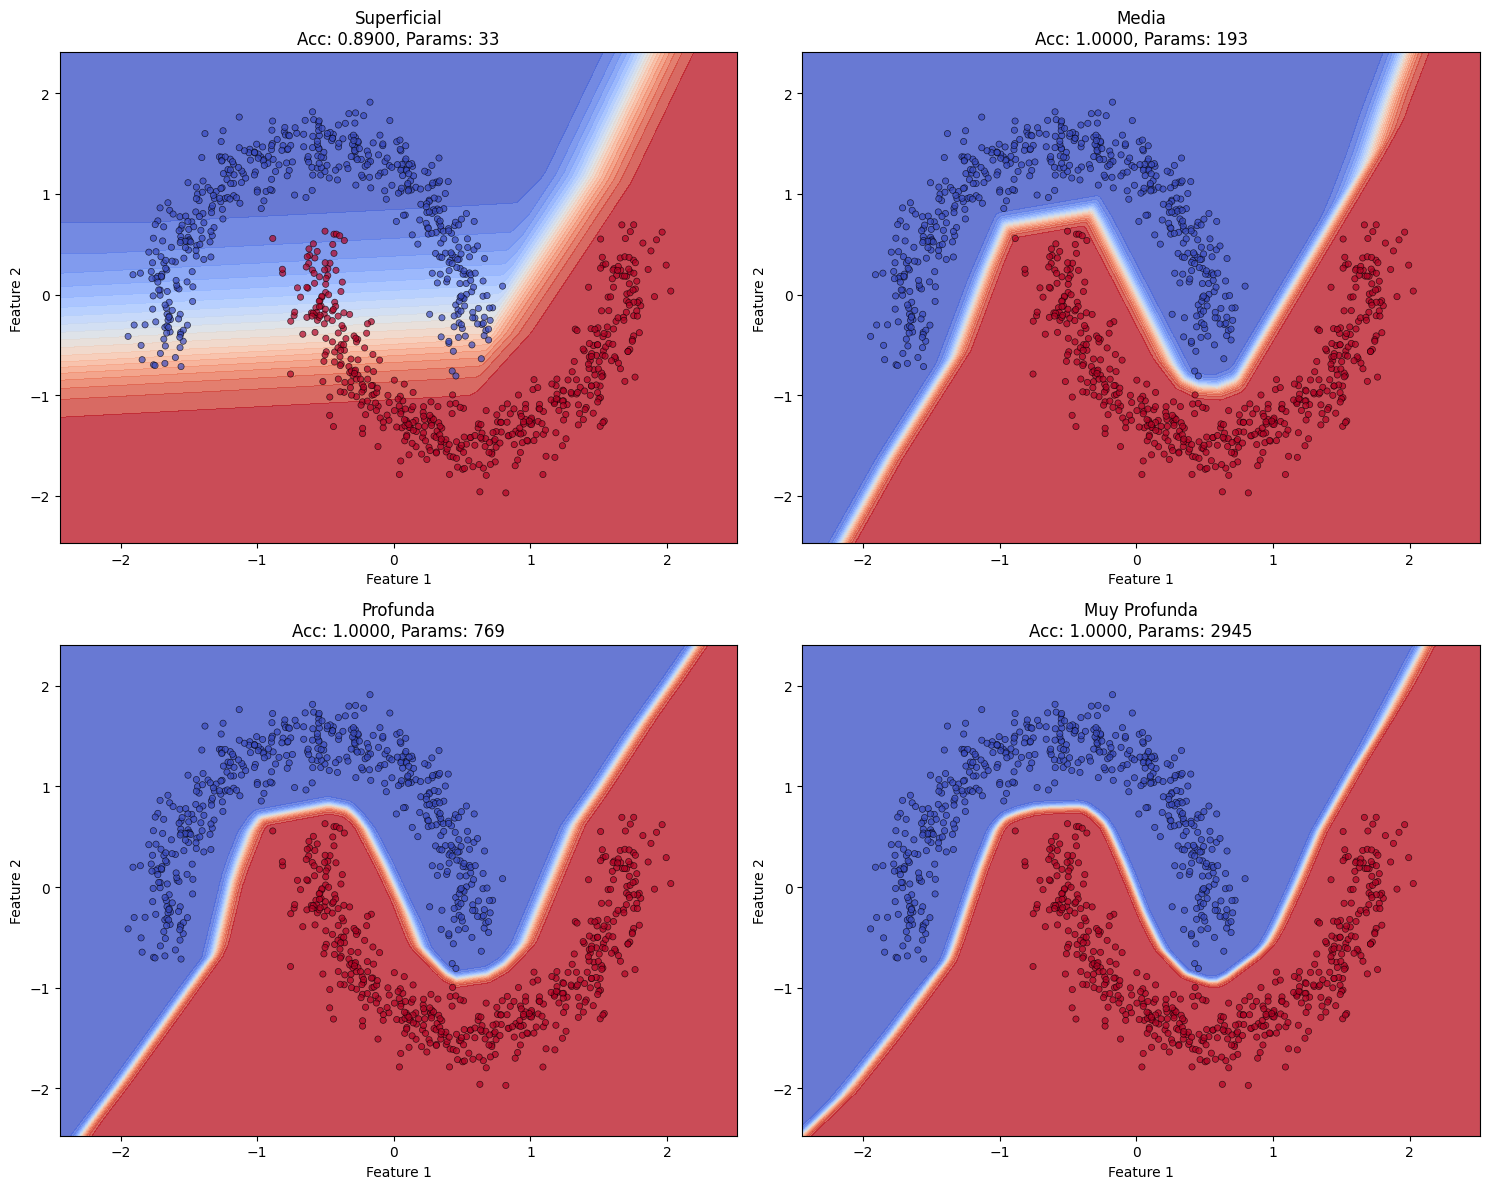

In [24]:
# Entrenar diferentes arquitecturas en el dataset de lunas
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)

# Diferentes arquitecturas
architectures = {
    'Superficial': [8],
    'Media': [16, 8],
    'Profunda': [32, 16, 8],
    'Muy Profunda': [64, 32, 16, 8]
}

results = {}

for name, hidden_sizes in architectures.items():
    print(f"\nEntrenando arquitectura {name}: {hidden_sizes}")
    model = DeepNN(input_size=2, hidden_sizes=hidden_sizes, output_size=1)
    train_losses, val_losses = train_model(
        model, X_train_t, y_train_t, X_test_t, y_test_t,
        epochs=500, lr=0.01, verbose=False
    )
    
    test_acc = evaluate_model(model, X_test_t, y_test_t)
    n_params = sum(p.numel() for p in model.parameters())
    
    results[name] = {
        'model': model,
        'accuracy': test_acc,
        'params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses
    }
    
    print(f"Precisión Test: {test_acc:.4f}, Parámetros: {n_params}")

# Visualizar resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    
    # Frontera de decisión
    X_vis = torch.FloatTensor(scaler.transform(X_moons))
    h = 0.02
    x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
    y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    mesh_input = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(mesh_input).numpy()
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm', levels=20)
    axes[idx].scatter(X_vis[:, 0], X_vis[:, 1], c=y_moons, cmap='coolwarm',
                     s=20, edgecolors='k', linewidth=0.5, alpha=0.7)
    axes[idx].set_title(f'{name}\nAcc: {result["accuracy"]:.4f}, '
                       f'Params: {result["params"]}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 5. Técnicas de Regularización

Para evitar el sobreajuste, usamos técnicas de regularización.

In [ ]:
class RegularizedNN(nn.Module):
    """Red neuronal con dropout."""
    
    def __init__(self, input_size, hidden_sizes, output_size, dropout_p=0.5):
        super(RegularizedNN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Crear modelos con y sin regularización
model_no_reg = DeepNN(input_size=2, hidden_sizes=[64, 32, 16], output_size=1)
model_with_reg = RegularizedNN(input_size=2, hidden_sizes=[64, 32, 16], 
                               output_size=1, dropout_p=0.3)

print("Modelo sin regularización:")
print(model_no_reg)
print(f"\nModelo con Dropout:")
print(model_with_reg)

## Ejercicios

1. Implementa una función que visualice la activación de cada capa oculta de la red.
2. Experimenta con diferentes funciones de activación (ReLU, tanh, sigmoid) y compara su rendimiento.
3. Implementa early stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.
4. Crea una función que compare el rendimiento de diferentes arquitecturas automáticamente.
5. Implementa L2 regularization (weight decay) manualmente y compáralo con dropout.

In [ ]:
# Espacio para ejercicios

## Resumen

En este notebook aprendimos:
- El perceptrón y sus limitaciones
- Funciones de activación y su importancia
- Redes neuronales multicapa (MLP)
- Redes profundas con múltiples capas ocultas
- Entrenamiento y evaluación de modelos
- Técnicas de regularización
- Comparación de diferentes arquitecturas

### Conceptos Clave
- Las redes profundas pueden aprender representaciones más complejas
- La elección de la arquitectura es un balance entre capacidad y generalización
- La regularización es crucial para evitar el sobreajuste
- La visualización de fronteras de decisión ayuda a entender el comportamiento del modelo